In [1]:
%load_ext autoreload
%autoreload 2
#import qRegNN_NFs as qrnn
#from trainingTools_QR import NFTrainer
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
device = torch.device('cuda:0')

def minmax(x,bound=3):
    return 2*bound*((x-x.min(axis=0))/(x.max(axis=0)-x.min(axis=0))-0.5)

# Moons, same x distribution

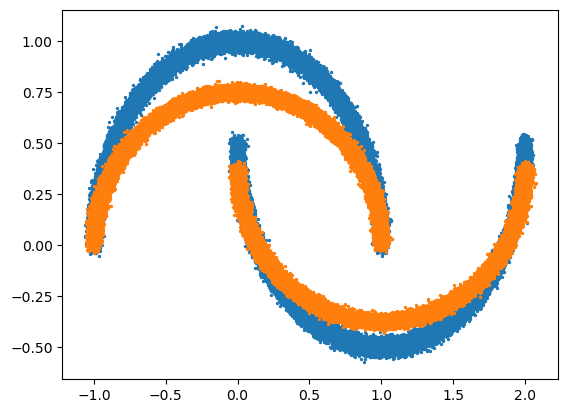

In [45]:
rangeScale = 3

btrain,l1 = datasets.make_moons(100000,noise=0.02)
btest,l2 = datasets.make_moons(100000,noise=0.02)

dtrain,l2 = datasets.make_moons(100000,noise=0.02)
dtest,l2 = datasets.make_moons(100000,noise=0.02)
dtrain[:,1] *= 0.75
dtest[:,1] *= 0.75

plt.scatter(btrain[:,0],btrain[:,1],s=2)
plt.scatter(dtrain[:,0],dtrain[:,1],s=2)

In [46]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer("moons",btrain,btest,dtrain,dtest,['x','y'],control=[0],NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=True)

RUNNING TRAININGS
Training flow bkgFlow_step0_y


Loss: -0.28271622091531756, p = 1: 100%|██████████| 500/500 [02:07<00:00,  3.92it/s] 


Training flow dataFlow_step0_y


Loss: -0.29670740306377413, p = 52: 100%|██████████| 500/500 [02:07<00:00,  3.93it/s]  


CORRECTING BKG


100%|██████████| 11/11 [00:01<00:00,  8.53it/s]


PLOTTING CORRECTIONS


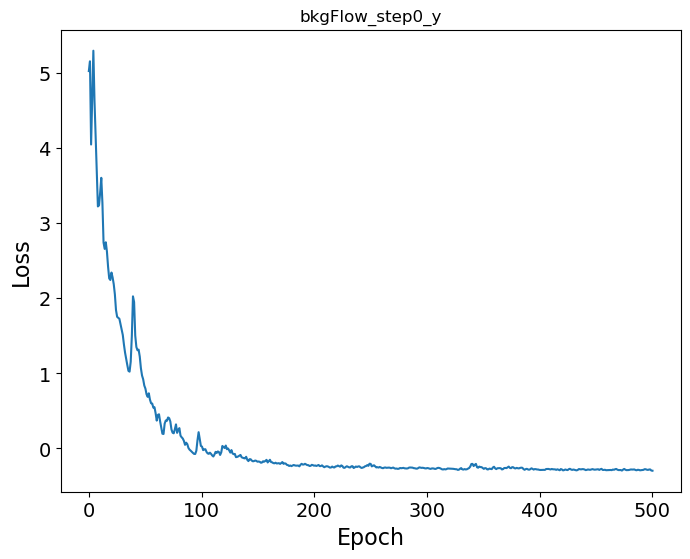

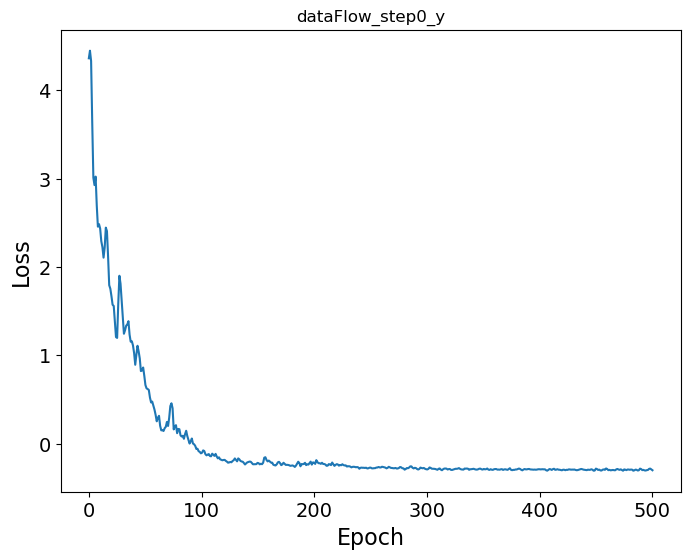

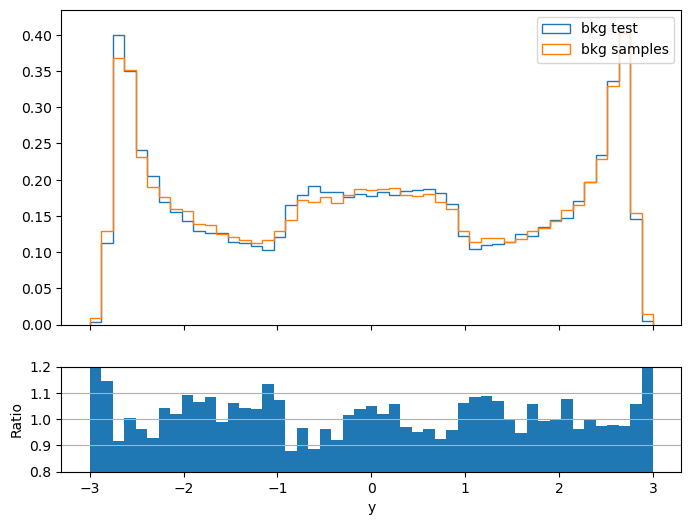

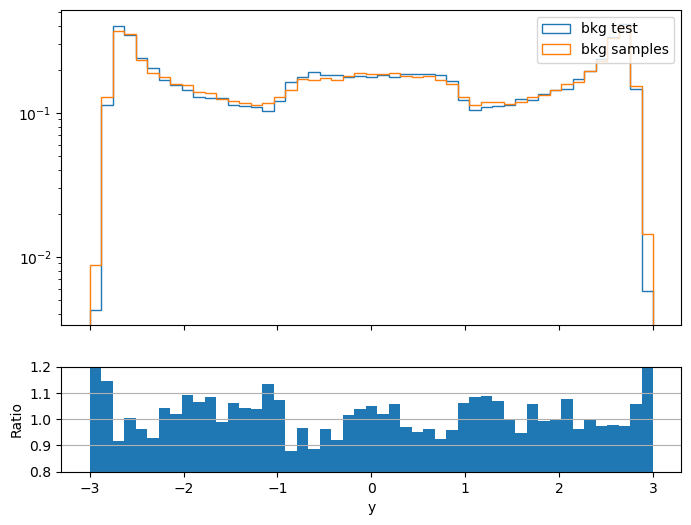

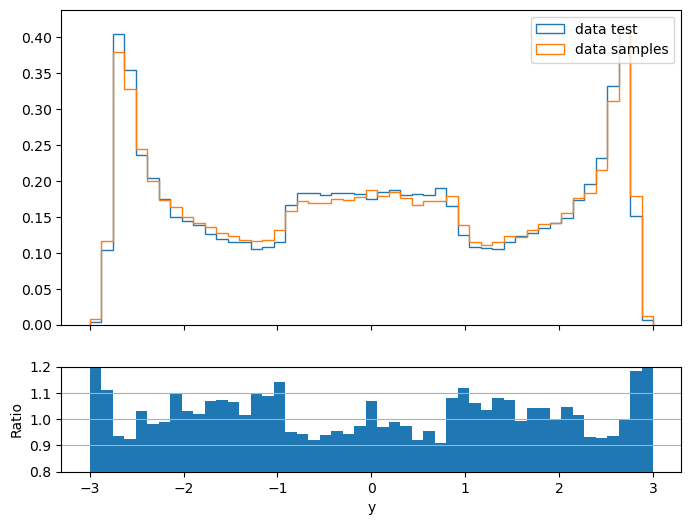

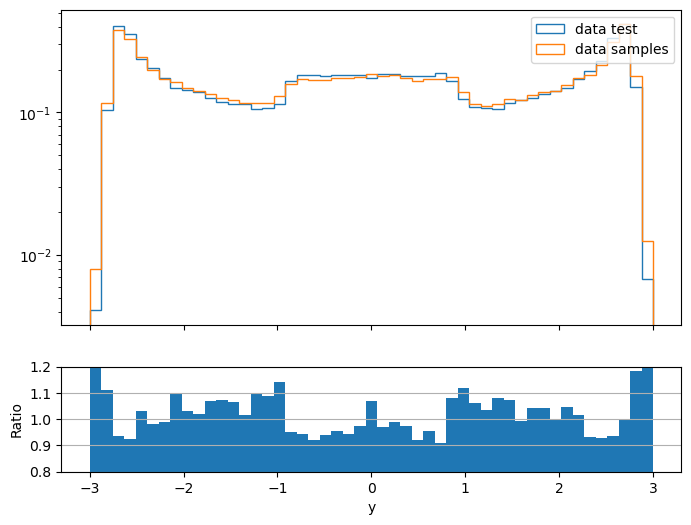

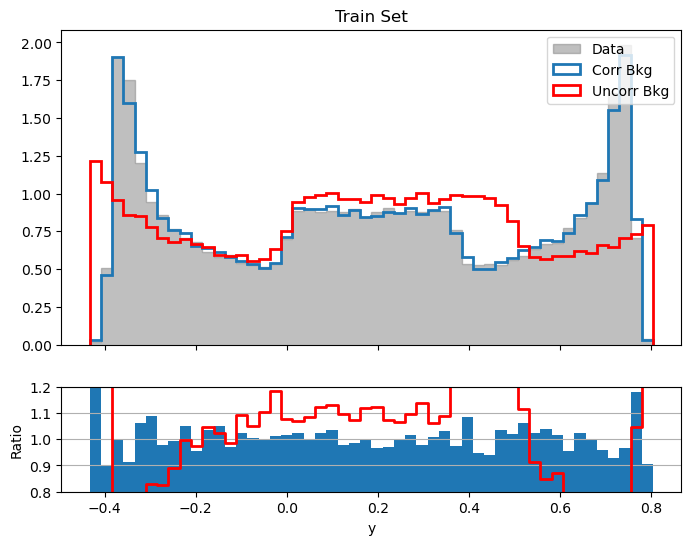

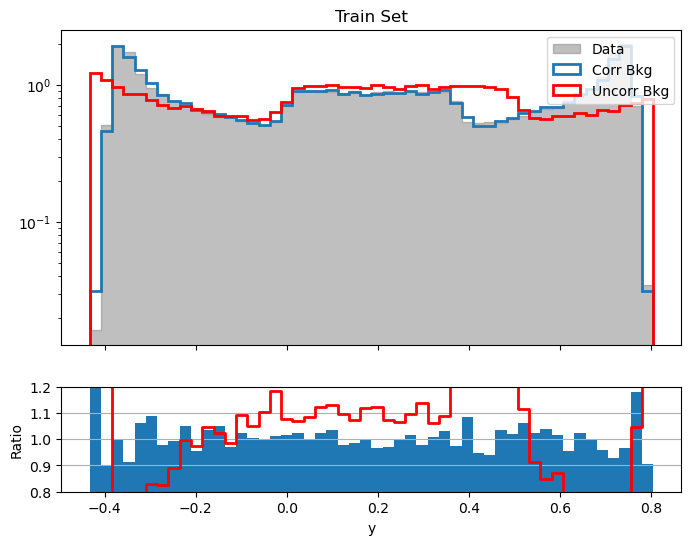

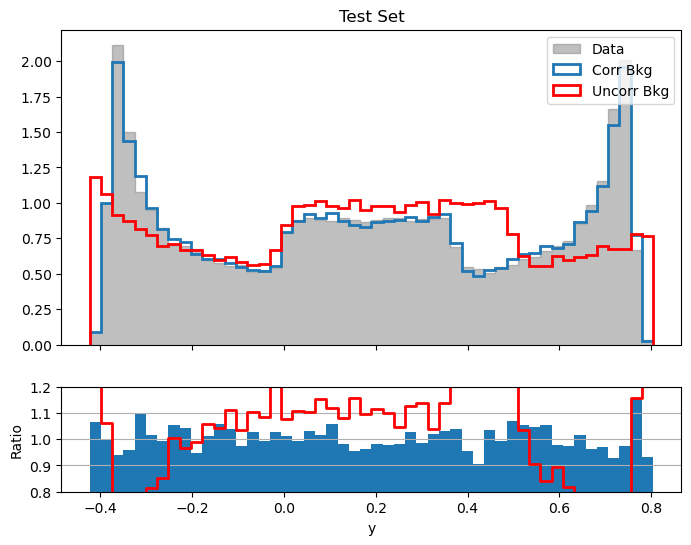

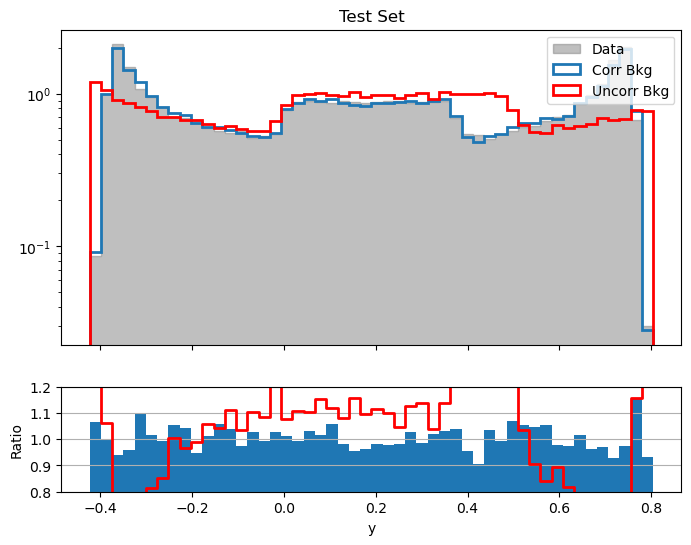

In [47]:
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 50
n_iter = n_epoch*btrain.shape[0]//bs
trainer.runCurrent(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)

In [48]:
b,l1 = datasets.make_moons(100000,noise=0.02)
d,l2 = datasets.make_moons(100000,noise=0.02)
d[:,1] *= 0.75
bcorr = trainer.correctFull(b)
fitvars = ['x','y']
bcorr = np.concatenate([bcorr[v] for v in fitvars],axis=1)

100%|██████████| 11/11 [00:00<00:00, 21.31it/s]


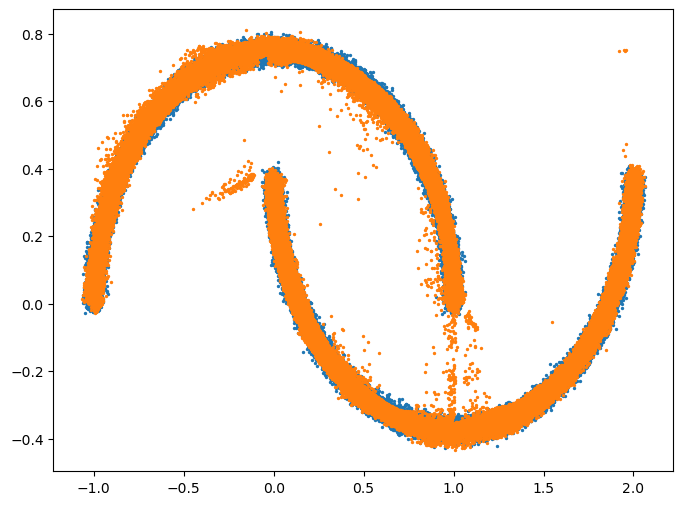

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(d[:,0],d[:,1],s=2)
plt.scatter(bcorr[:,0],bcorr[:,1],s=2)

# Moons to checkerboard

In [3]:
from datasets import CheckerboardDataset

btrain,l1 = datasets.make_moons(500000,noise=0.02)
btest,l2 = datasets.make_moons(100000,noise=0.02)

dtrain = CheckerboardDataset(num_points=500000)[:].cpu().numpy()
dtest = CheckerboardDataset(num_points=100000)[:].cpu().numpy()

In [3]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":100,
             "num_layers":10,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer("moons2check",btrain,btest,dtrain,dtest,['x','y'],control=[],NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=True)

Training flow bkgFlow_step0_x


Loss: 1.6342059564590454, p = 541: 100%|██████████| 2441/2441 [02:43<00:00, 14.95it/s]


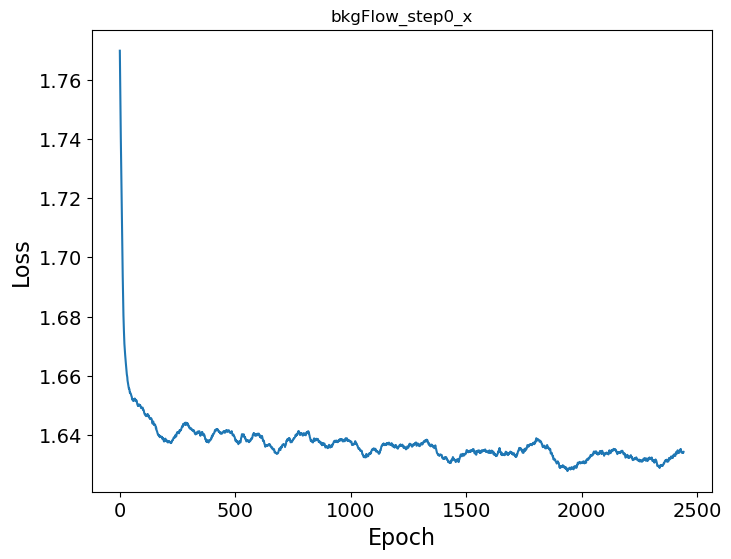

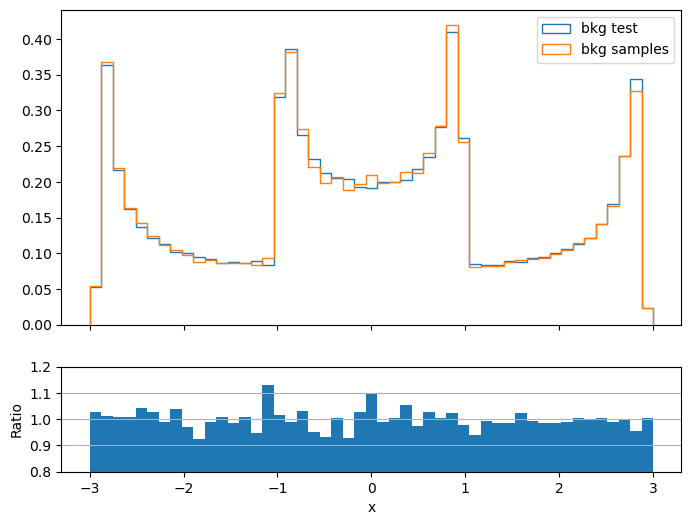

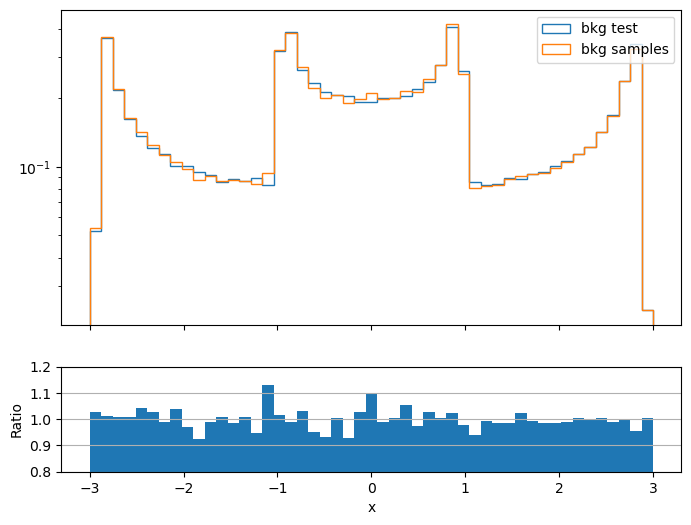

In [5]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3,"hidden_features":150,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear","reisdual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 5
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=5e-4,bs=bs,anneal=True)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_x


Loss: 1.797814164161682, p = 621: 100%|██████████| 2441/2441 [02:44<00:00, 14.83it/s] 


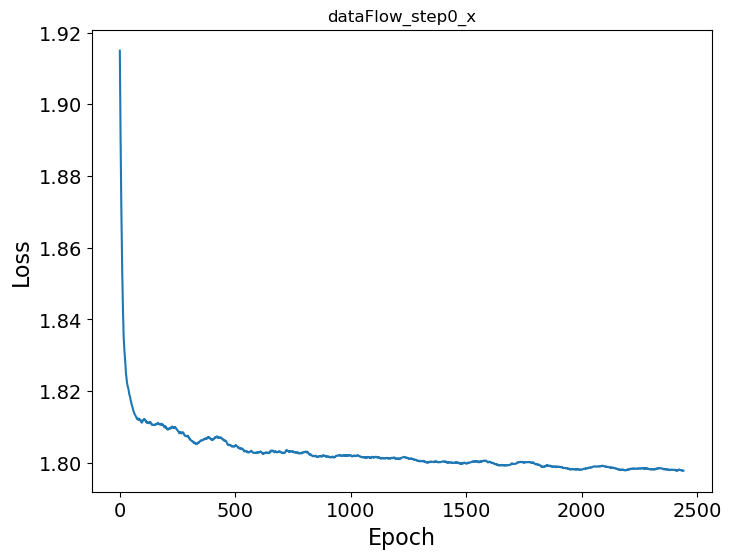

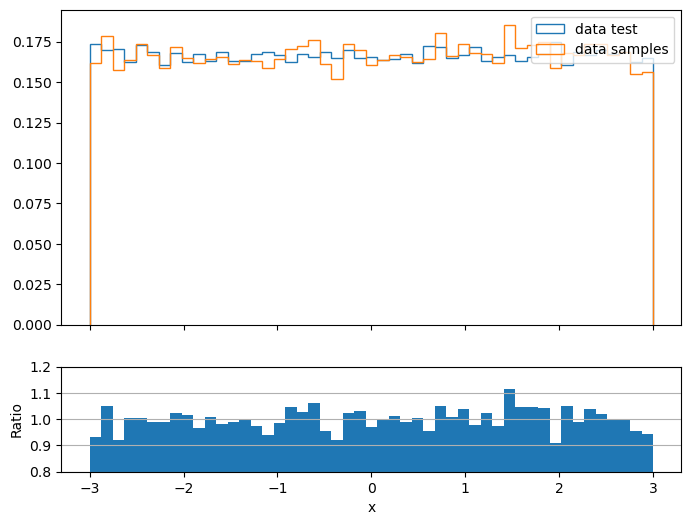

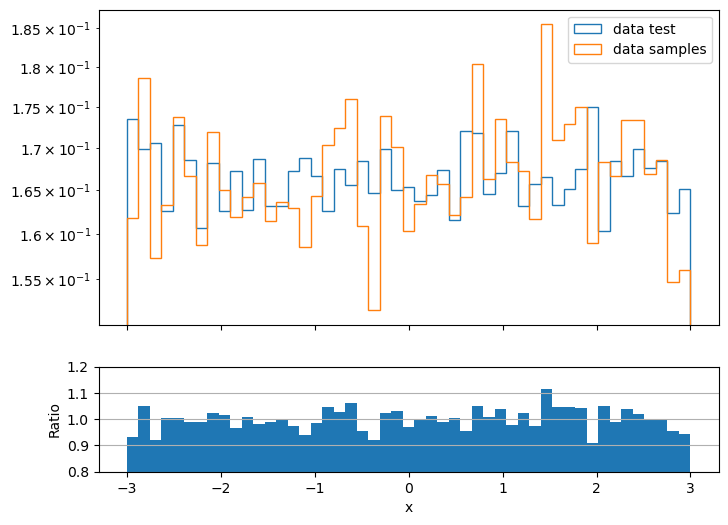

In [6]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3,"hidden_features":150,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 5
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=5e-4,bs=bs,anneal=True)
trainer.plotDensity(data=True)

100%|██████████| 11/11 [00:00<00:00, 13.56it/s]


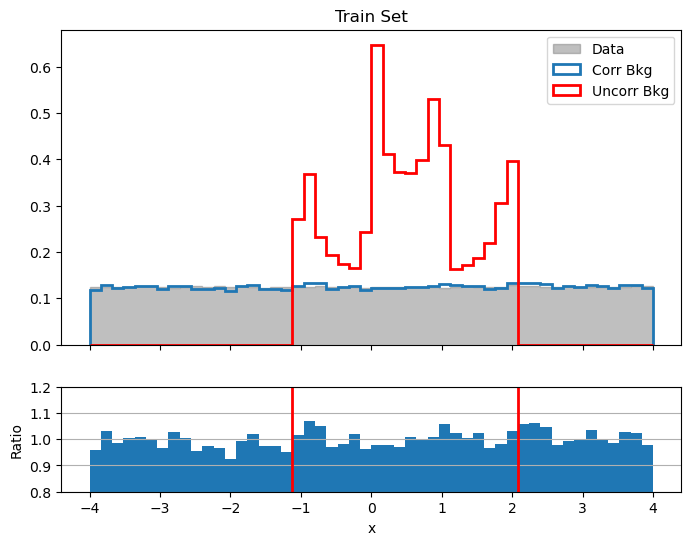

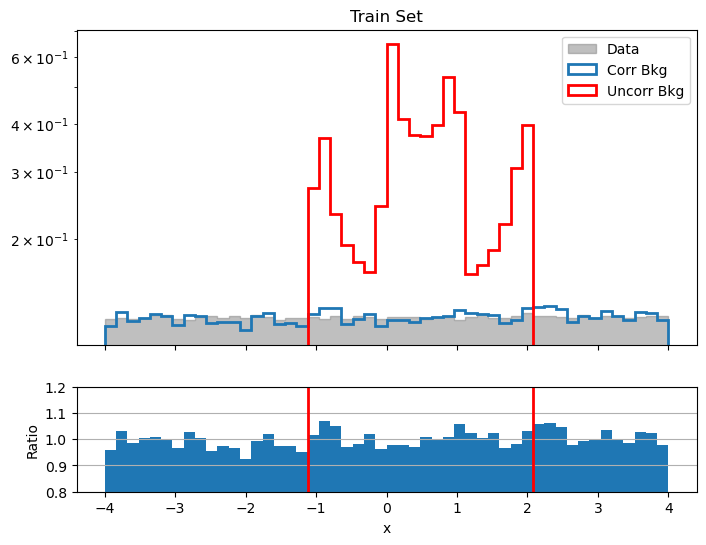

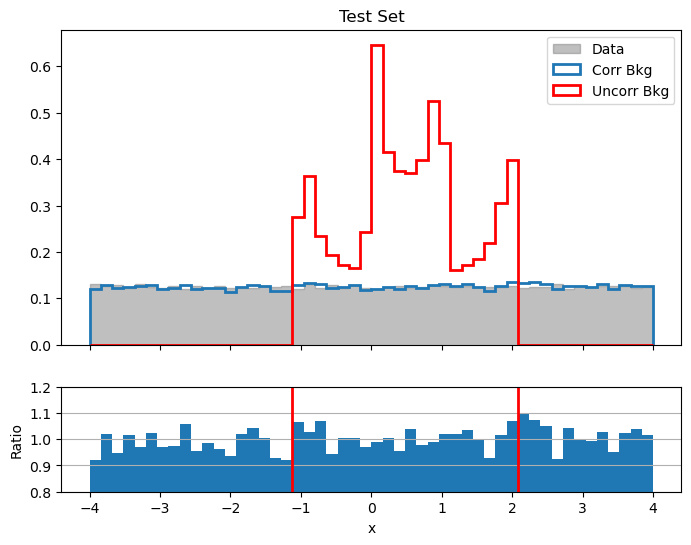

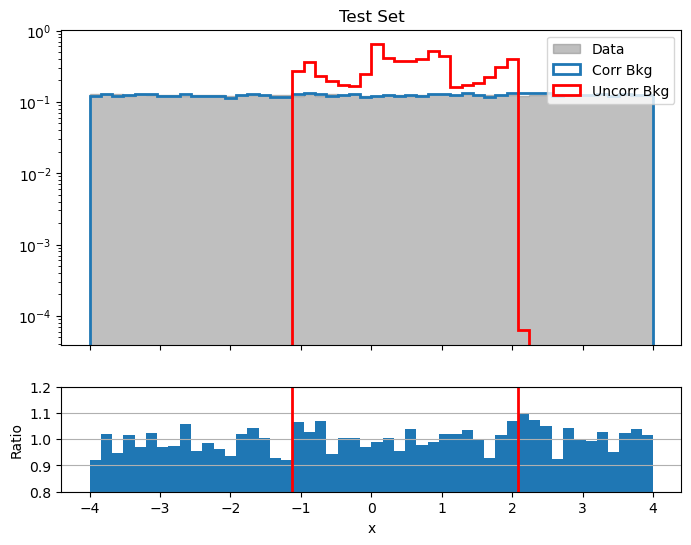

In [7]:
trainer.correctCurrent()
trainer.plotCurrent(50)

In [8]:
trainer.stepForward()

Training flow bkgFlow_step1_y


Loss: -0.3284056478738785, p = 232: 100%|██████████| 5000/5000 [20:20<00:00,  4.10it/s] 


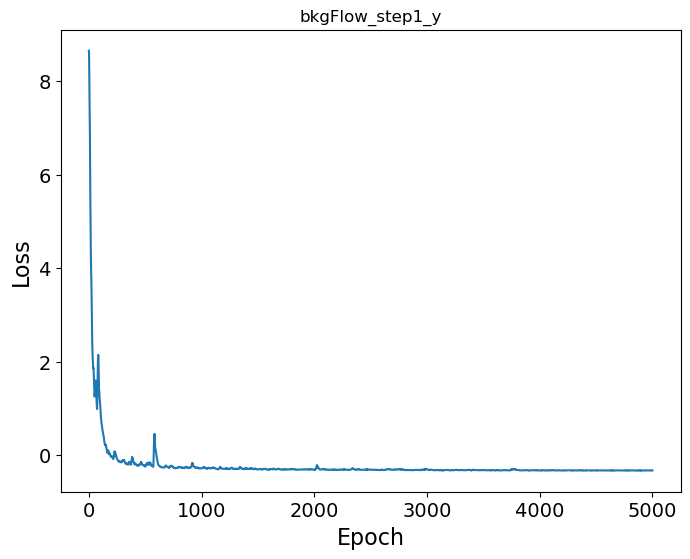

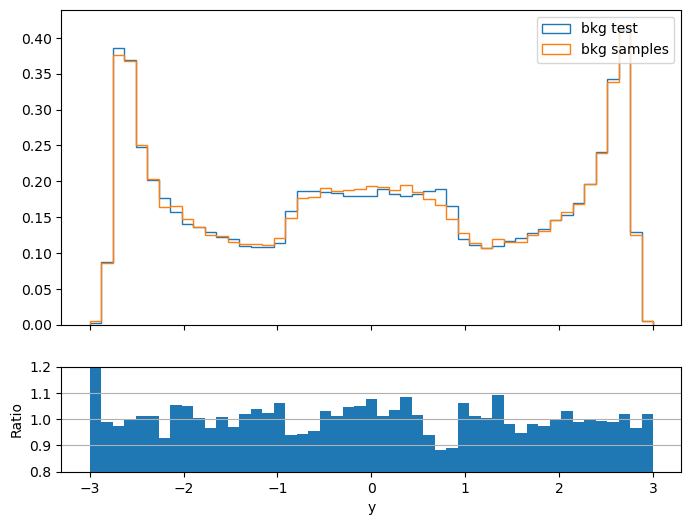

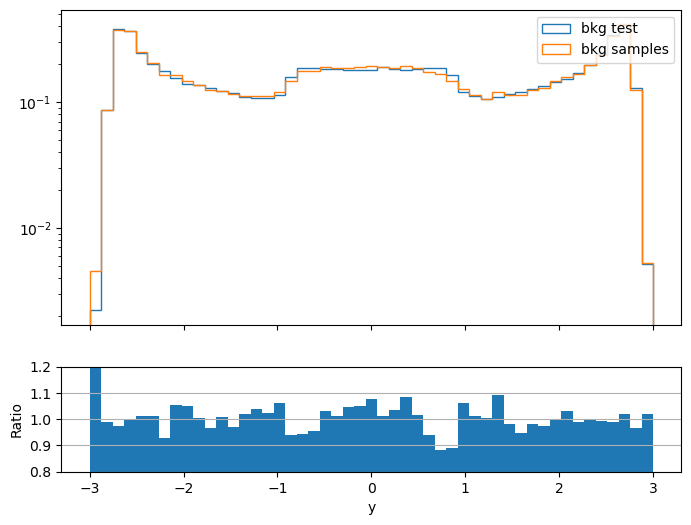

In [11]:
#NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":100,
#             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":50,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 100
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_y


Loss: 1.1411096549034119, p = 10: 100%|██████████| 1000/1000 [04:10<00:00,  3.99it/s]


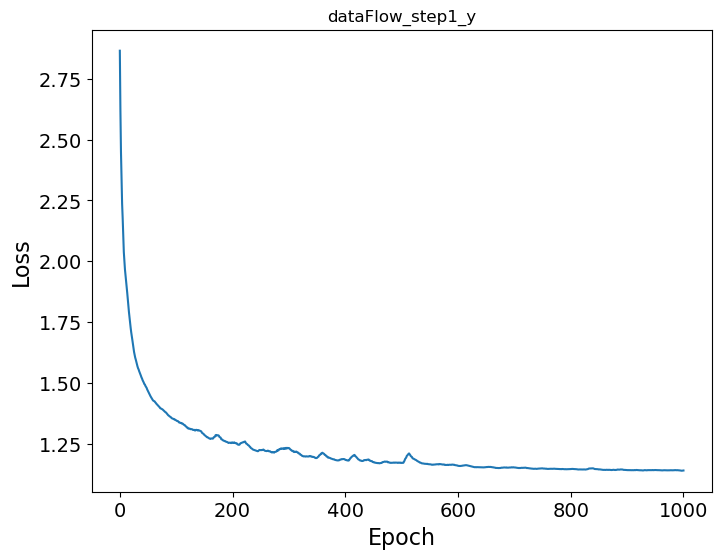

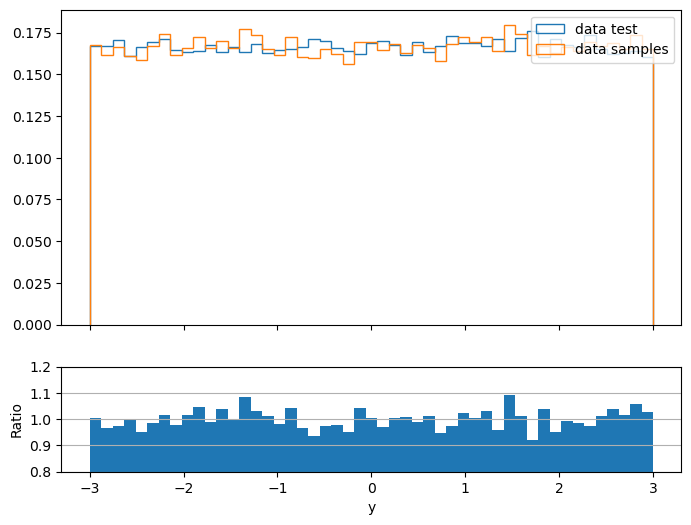

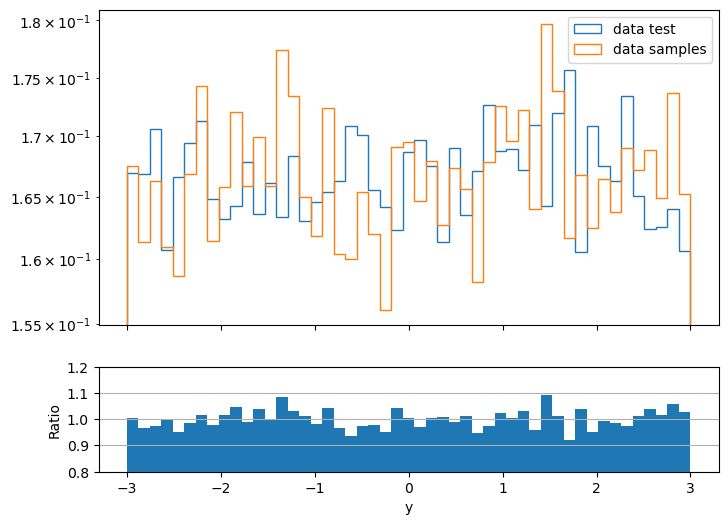

In [12]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":50,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(data=True)

[]


100%|██████████| 11/11 [00:00<00:00, 20.29it/s]


[0]


100%|██████████| 11/11 [00:00<00:00, 21.71it/s]


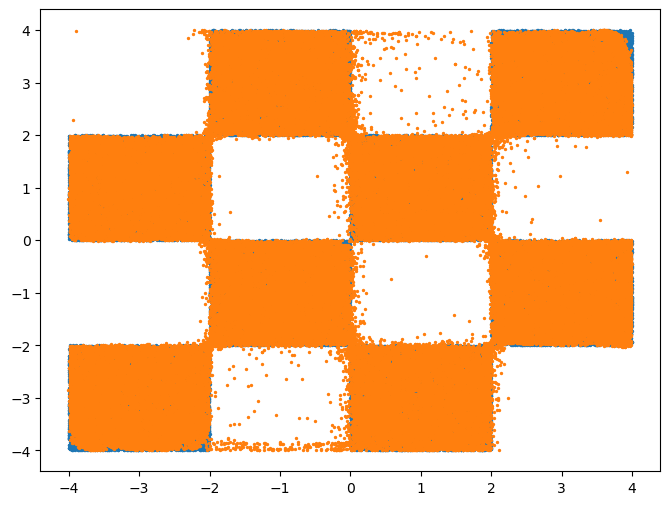

In [2]:
from datasets import CheckerboardDataset

corrector = qrnn.chainedNFCorrector("NF_models_QR_general/moons2check/")

b,l1 = datasets.make_moons(100000,noise=0.02)
d = CheckerboardDataset(num_points=100000)[:].cpu().numpy()

bcorr = corrector.correctFull(b)
fitvars = ['x','y']
bcorr = np.concatenate([bcorr[v] for v in fitvars],axis=1)

plt.figure(figsize=(8,6))
plt.scatter(d[:,0],d[:,1],s=2)
plt.scatter(bcorr[:,0],bcorr[:,1],s=2)

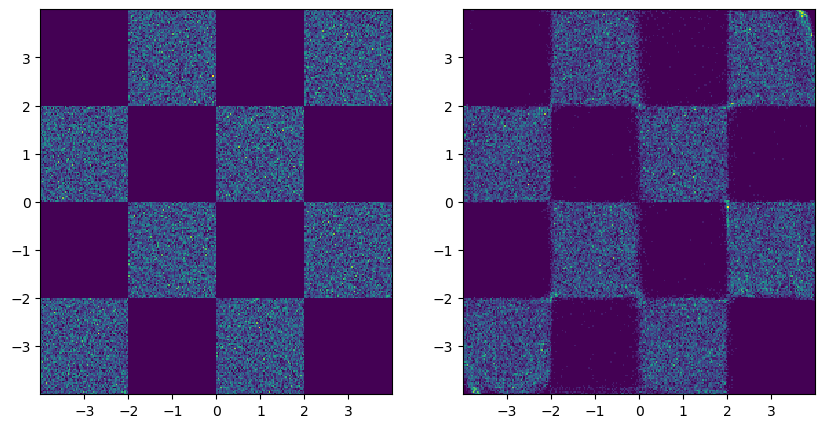

In [3]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
h1,bx,by,_= axes[0].hist2d(d[:,0],d[:,1],bins=256,rasterized=False)
h2,bx,by,_= axes[1].hist2d(bcorr[:,0],bcorr[:,1],bins=(bx,by),rasterized=False)

In [30]:
x0 = b[:,0]
x1 = bcorr[:,0]
dx = x1-x0
nstep = 50

i0 = np.histogram2d(b[:,0],b[:,1],bins=(bx,by))[0]
images = 3*[i0]
for i in range(1,nstep+1):
    xstep = x0 + i*dx/nstep
    images.append(np.histogram2d(xstep,b[:,1],bins=(bx,by))[0])

y0 = b[:,1]
y1 = bcorr[:,1]
dy = y1-y0
nstep = 50
for i in range(1,nstep+1):
    ystep = y0 + i*dy/nstep
    images.append(np.histogram2d(bcorr[:,0],ystep,bins=(bx,by))[0])
last = images[-1]
for i in range(3):
    images.append(last)

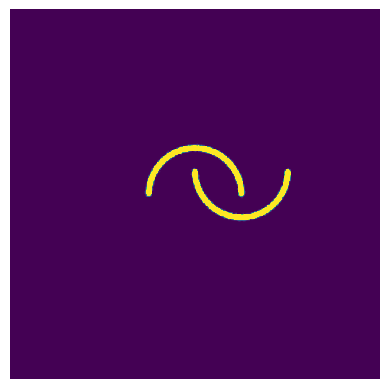

In [32]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
norm = Normalize(vmin=h1.min(),vmax=h1.max())

images = images + images[::-1]

fig = plt.figure()
im = plt.imshow(images[0].T,origin='lower',animated=True,norm=norm)
plt.axis('off')


def updatefig(frame):
    im.set_array(frame.T)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=images, interval=40, blit=True)
writer = animation.PillowWriter(fps=25,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
ani.save('NF_models_QR_general/moons2check/moon2check.gif', writer=writer)

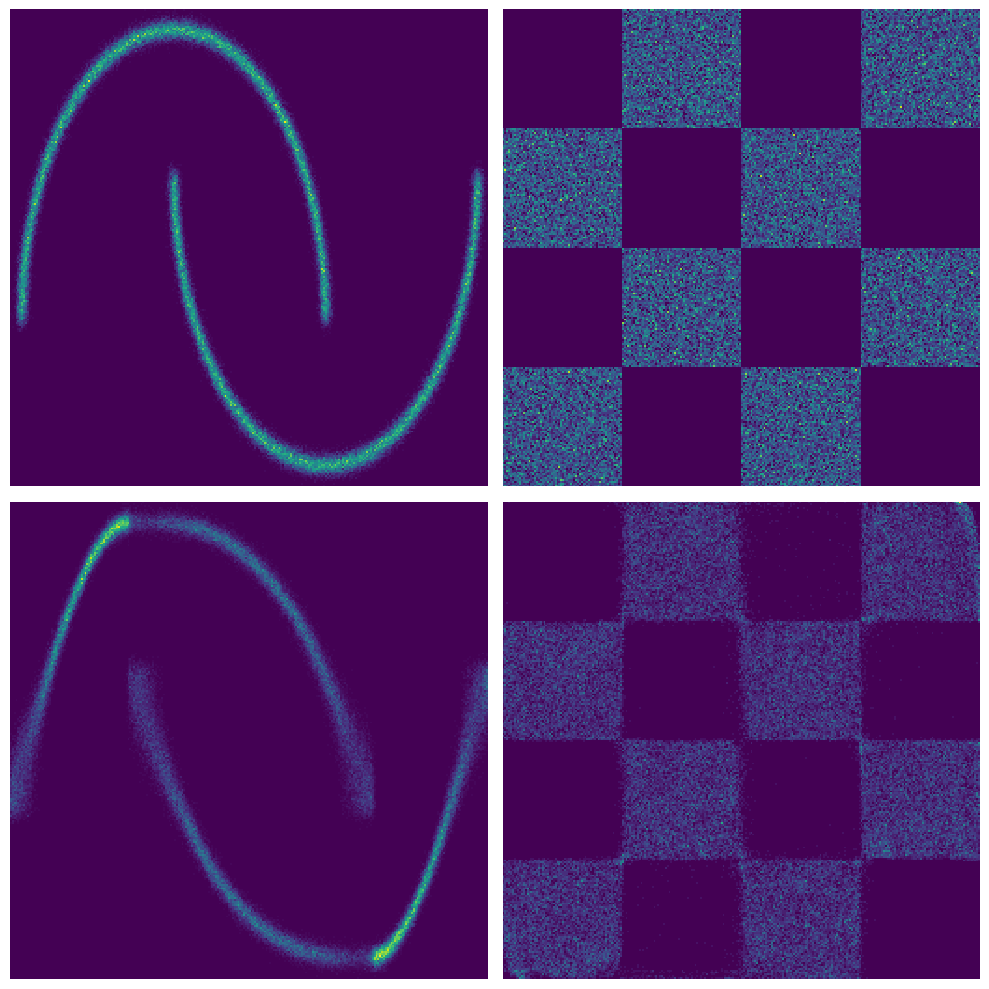

In [3]:
sb = minmax(b,bound=3)
sd = minmax(d,bound=3)
sbcorr = minmax(bcorr,bound=3)

fig,axes = plt.subplots(2,2,figsize=(10,10))
h1,bx,by,_ = axes[0,0].hist2d(sb[:,0],sb[:,1],bins=(256,256))
axes[0,0].axis('off')
h1 = axes[0,1].hist2d(sd[:,0],sd[:,1],bins=(bx,by))
axes[0,1].axis('off')
h1 = axes[1,0].hist2d(sbcorr[:,0],sb[:,1],bins=(bx,by))
axes[1,0].axis('off')
h1 = axes[1,1].hist2d(sbcorr[:,0],sbcorr[:,1],bins=(bx,by))
axes[1,1].axis('off')
plt.tight_layout()
#plt.savefig("NF_models_QR_general/moons2check/mooncheck_fulltransition.png")

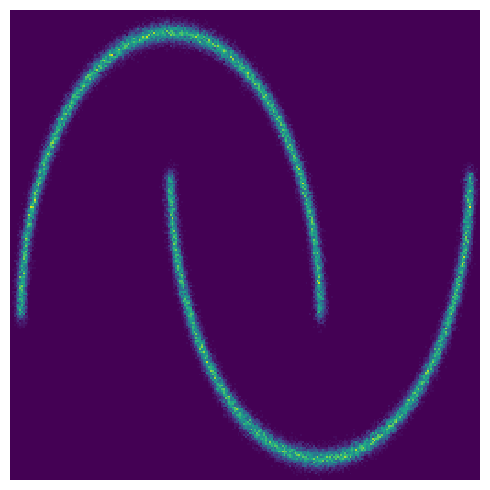

In [12]:
plt.figure(figsize=(5,5))
h = plt.hist2d(sb[:,0],sb[:,1],bins=(bx,by))
plt.axis('off')
plt.tight_layout()
plt.savefig("NF_models_QR_general/moons2check/moons.png")

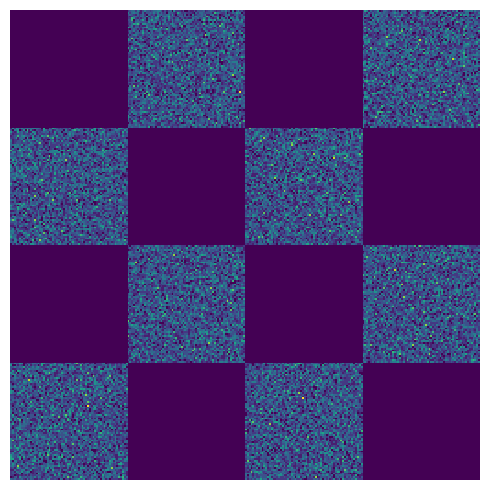

In [13]:
plt.figure(figsize=(5,5))
h = plt.hist2d(sd[:,0],sd[:,1],bins=(bx,by))
plt.axis('off')
plt.tight_layout()
plt.savefig("NF_models_QR_general/moons2check/check.png")

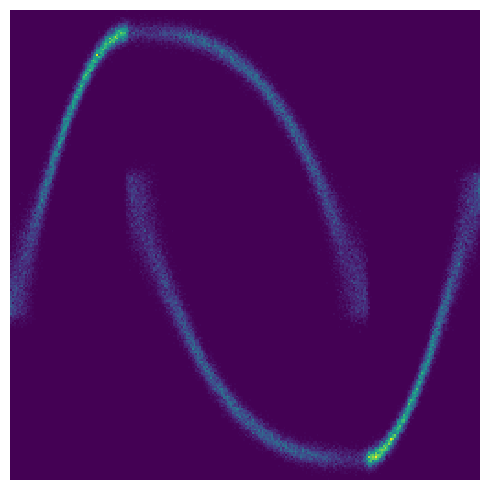

In [14]:
plt.figure(figsize=(5,5))
h = plt.hist2d(sbcorr[:,0],sb[:,1],bins=(bx,by))
plt.axis('off')
plt.tight_layout()
plt.savefig("NF_models_QR_general/moons2check/moons_halfway.png")

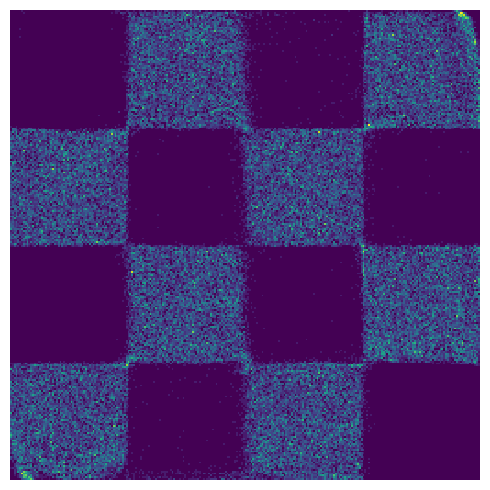

In [15]:
plt.figure(figsize=(5,5))
h = plt.hist2d(sbcorr[:,0],sbcorr[:,1],bins=(bx,by))
plt.axis('off')
plt.tight_layout()
plt.savefig("NF_models_QR_general/moons2check/moons_fulltransform.png")

In [15]:
x0 = sb[:,0]
x1 = sbcorr[:,0]
dx = x1-x0
nstep = 50

i0,bx,by = np.histogram2d(sb[:,0],sb[:,1],bins=(256,256))
images = 3*[i0]
for i in range(1,nstep+1):
    xstep = x0 + i*dx/nstep
    images.append(np.histogram2d(xstep,sb[:,1],bins=(bx,by))[0])

y0 = sb[:,1]
y1 = sbcorr[:,1]
dy = y1-y0
nstep = 50
for i in range(1,nstep+1):
    ystep = y0 + i*dy/nstep
    images.append(np.histogram2d(sbcorr[:,0],ystep,bins=(bx,by))[0])
last = images[-1]
for i in range(3):
    images.append(last)

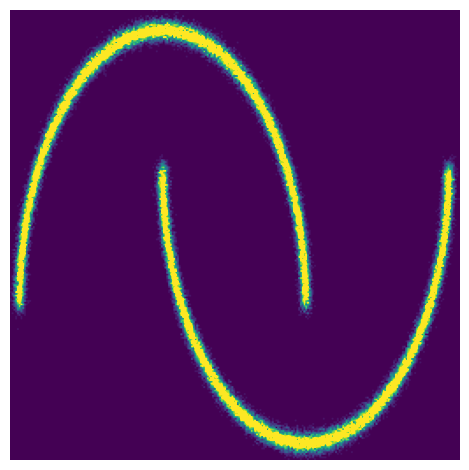

In [16]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
vmin = images[-1].min()
vmax = images[-1].max()
norm = Normalize(vmin=vmin,vmax=vmax)

images = images + images[::-1]

fig = plt.figure()
im = plt.imshow(images[0].T,origin='lower',animated=True,norm=norm)
plt.axis('off')
plt.tight_layout()

def updatefig(frame):
    im.set_array(frame.T)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=images, interval=40, blit=True)
writer = animation.PillowWriter(fps=25,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
ani.save('NF_models_QR_general/moons2check/moon2check.gif', writer=writer)

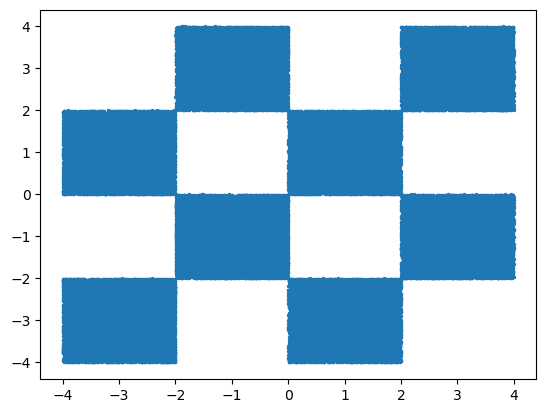

In [46]:
plt.scatter(d[:,0],d[:,1],s=2)

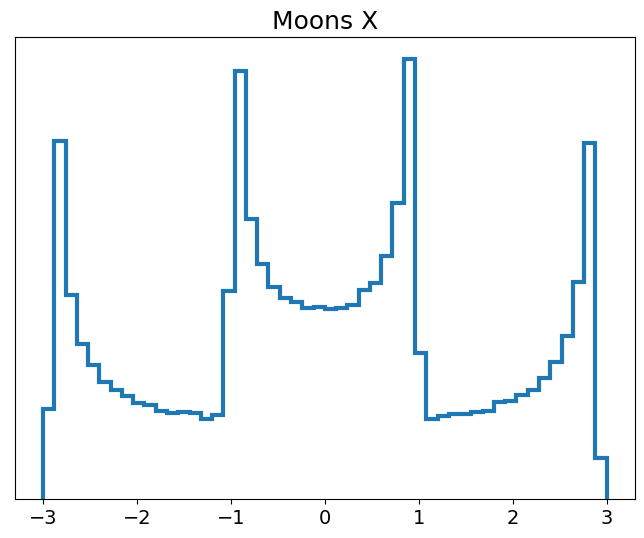

In [41]:
plt.figure(figsize=(8,6))
h1 = plt.hist(sb[:,0],bins=50,histtype='step',density=True,linewidth=3)
plt.title('Moons X',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/moons_x.pdf")

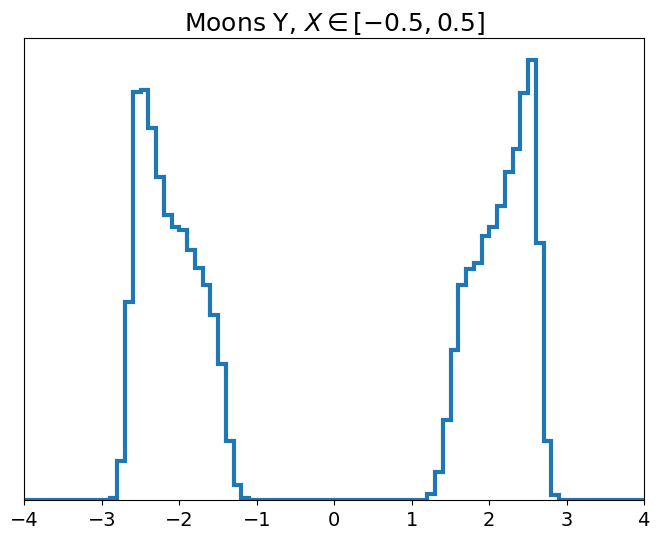

In [7]:
plt.figure(figsize=(8,6))
bins=np.arange(-4,4.1,0.1)
h1 = plt.hist(sb[:,1][np.abs(sb[:,0])<0.5],bins=bins,histtype='step',density=True,linewidth=3)
plt.title(r'Moons Y, $X \in [-0.5,0.5]$',fontsize=18)
plt.xlim([-4,4])
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/moons_y_xCenter.pdf")

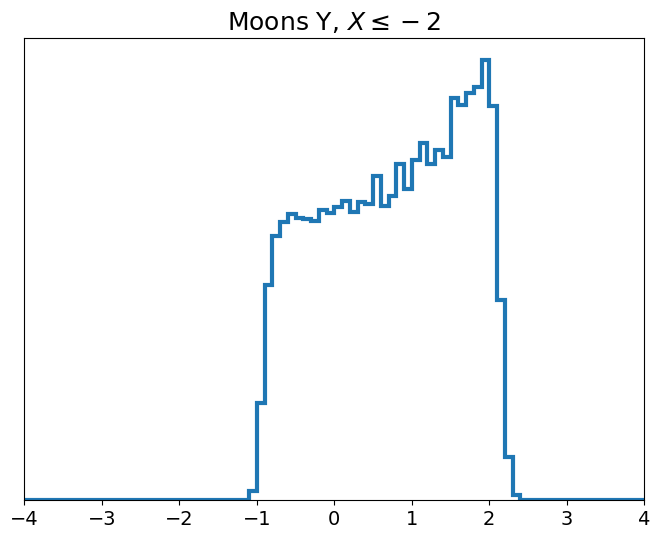

In [6]:
plt.figure(figsize=(8,6))
bins=np.arange(-4,4.1,0.1)
h1 = plt.hist(sb[:,1][sb[:,0]<-2],bins=bins,histtype='step',density=True,linewidth=3)
plt.xlim([-4,4])
plt.title(r'Moons Y, $X \leq -2$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/moons_y_xLeft.pdf")

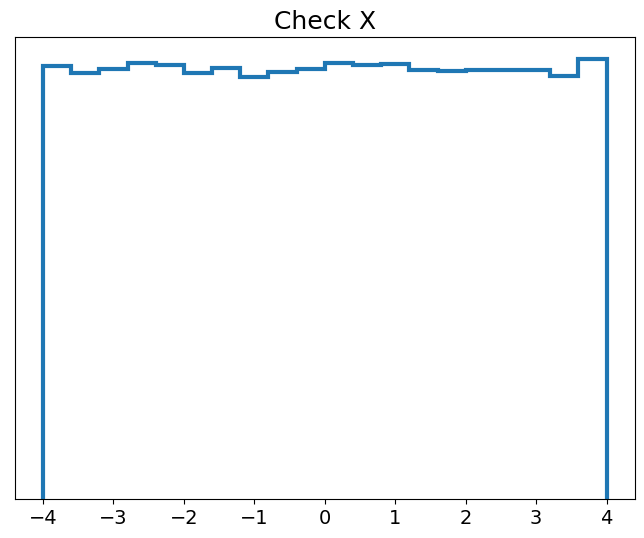

In [51]:
plt.figure(figsize=(8,6))
h1 = plt.hist(d[:,0],bins=20,histtype='step',density=True,linewidth=3)
plt.title('Check X',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/check_x.pdf")

(-4.0, 4.0)

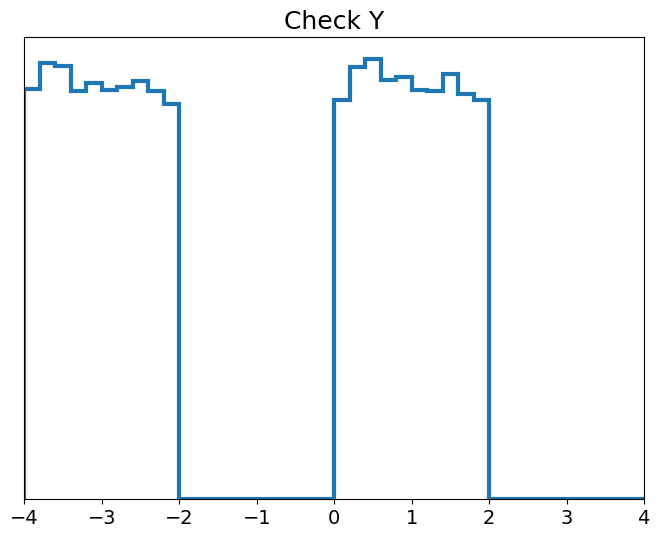

In [60]:
plt.figure(figsize=(8,6))
bins=np.arange(-4,4.2,0.2)
h1 = plt.hist(d[:,1][(d[:,0]>-3.9)&(d[:,0]<-2.1)],bins=bins,histtype='step',density=True,linewidth=3)
plt.title(r'Check Y',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/check_y_x1.pdf")
plt.xlim([-4,4])

(-4.0, 4.0)

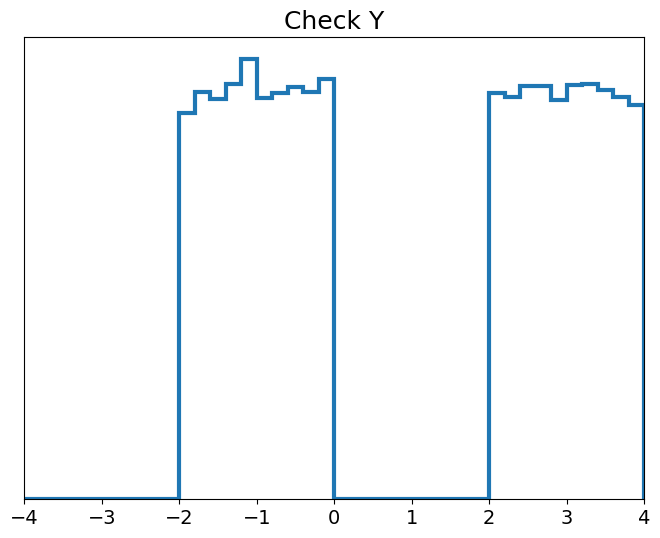

In [62]:
plt.figure(figsize=(8,6))
bins=np.arange(-4,4.2,0.2)
h1 = plt.hist(d[:,1][(d[:,0]>-1.8)&(d[:,0]<-0.2)],bins=bins,histtype='step',density=True,linewidth=3)
plt.title(r'Check Y',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks([])
plt.savefig("NF_models_QR_general/moons2check/check_y_x2.pdf")
plt.xlim([-4,4])

# Mapping with regular NFs

In [19]:
from datasets import CheckerboardDataset

btrain,l1 = datasets.make_moons(100000,noise=0.02)
btest,l2 = datasets.make_moons(100000,noise=0.02)

dtrain = CheckerboardDataset(num_points=100000)[:].cpu().numpy()
dtest = CheckerboardDataset(num_points=100000)[:].cpu().numpy()

btrain = minmax(btrain)
btest = minmax(btest)
dtrain = minmax(dtrain)
dtest = minmax(dtest)

Training flow


Loss: 1.4035002636909484, p = 327: 100%|██████████| 976/976 [01:17<00:00, 12.65it/s]


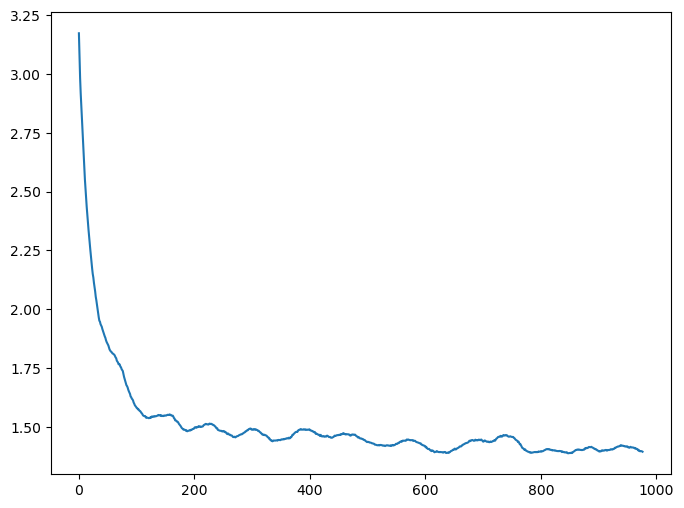

In [34]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.5,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
flow1 = qrnn.make_flow(2,num_context=0,kwargs=NF_kwargs,perm=True)
flow1 = qrnn.train_flow(flow1,btrain,context=None,n_epoch=5,lr=1e-3,bs=512,wd=0.0,patience=-1,n_avg=100,anneal=True)

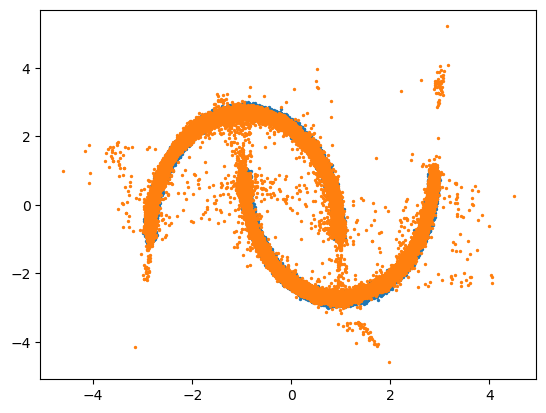

In [35]:
flow1 = flow1.to(device)
with torch.no_grad():
    samples = flow1.sample(100000).detach().cpu().numpy()
flow1 = flow1.to('cpu')
plt.figure()
s1 = plt.scatter(btest[:,0],btest[:,1],s=2)
s1 = plt.scatter(samples[:,0],samples[:,1],s=2)

# Moons to checkerboard v2

In [30]:
from datasets import CheckerboardDataset

btrain,l1 = datasets.make_moons(100000,noise=0.02)
btest,l2 = datasets.make_moons(100000,noise=0.02)

dtrain = CheckerboardDataset(num_points=100000)[:].cpu().numpy()
dtest = CheckerboardDataset(num_points=100000)[:].cpu().numpy()

In [31]:
# pre-process to be in same range
def minmax(x,bound=3):
    return 2*bound*((x-x.min(axis=0))/(x.max(axis=0)-x.min(axis=0))-0.5)
btrain = minmax(btrain)
btest = minmax(btest)
dtrain = minmax(dtrain)
dtest = minmax(dtest)

In [32]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":100,
             "num_layers":10,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer("moons2check_v2",btrain,btest,dtrain,dtest,['x','y'],control=[],NF_kwargs=NF_kwargs,
                                rangeScale=rangeScale,separateScale=True,useScale=False)

Training flow bkgFlow_step0_x


Loss: 1.650176693201065, p = 2614: 100%|██████████| 3906/3906 [03:36<00:00, 18.06it/s] 


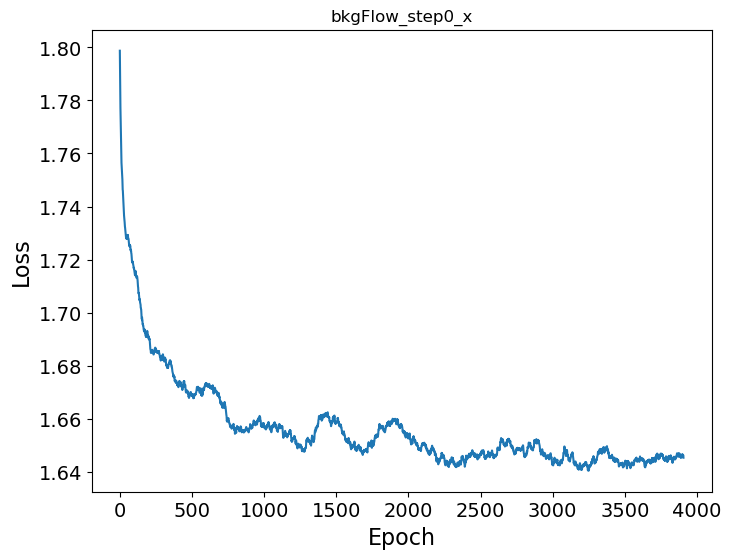

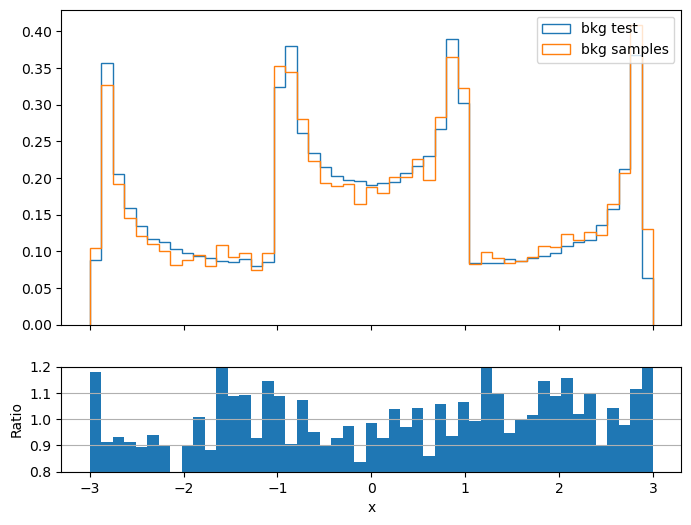

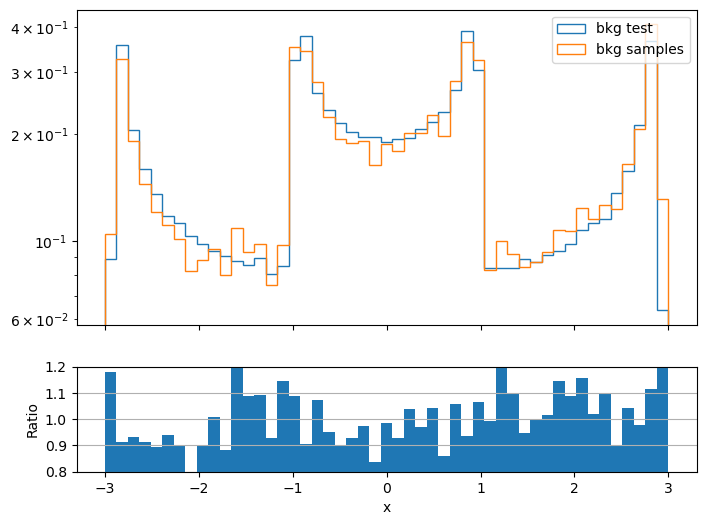

In [33]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3,"hidden_features":150,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear","reisdual":False}
trainer.NF_kwargs = NF_kwargs
bs = 512
n_epoch = 5
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_x


Loss: 1.7977339208126069, p = 75: 100%|██████████| 300/300 [00:38<00:00,  7.72it/s]


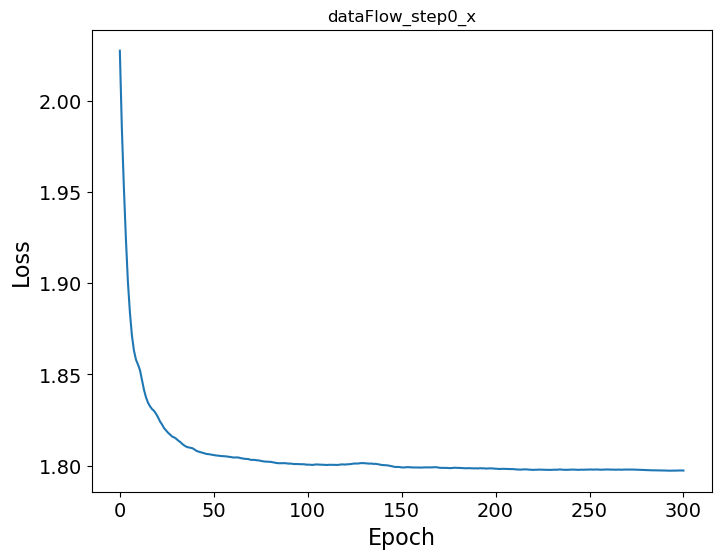

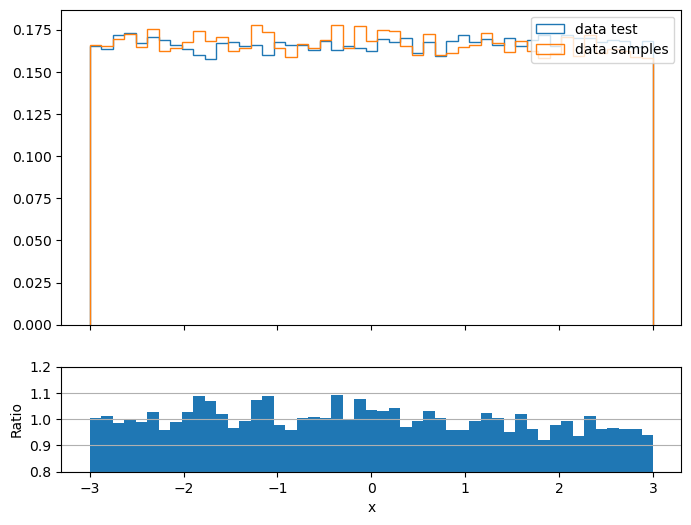

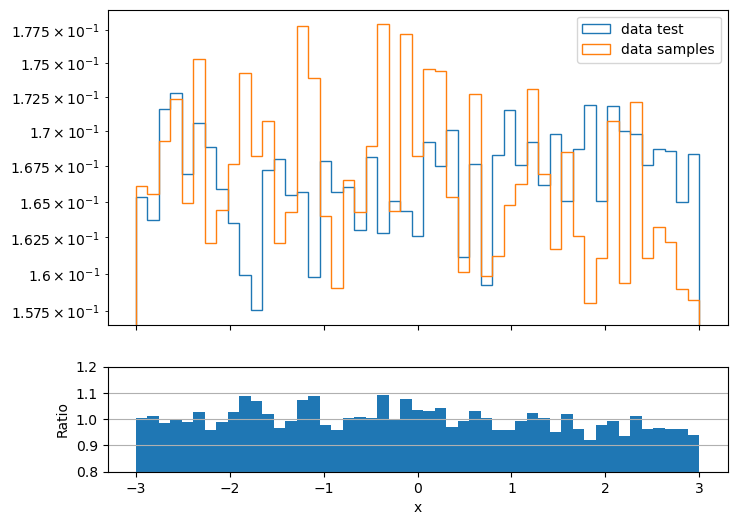

In [49]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 5000
n_epoch = 3
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(data=True)

In [ ]:
trainer.correctCurrent()
trainer.plotCurrent(50)

100%|██████████| 11/11 [00:01<00:00, 10.96it/s]


In [11]:
trainer.stepForward()

Training flow bkgFlow_step1_y


Loss: -0.3342321416735649, p = 455: 100%|██████████| 5000/5000 [19:54<00:00,  4.19it/s]  


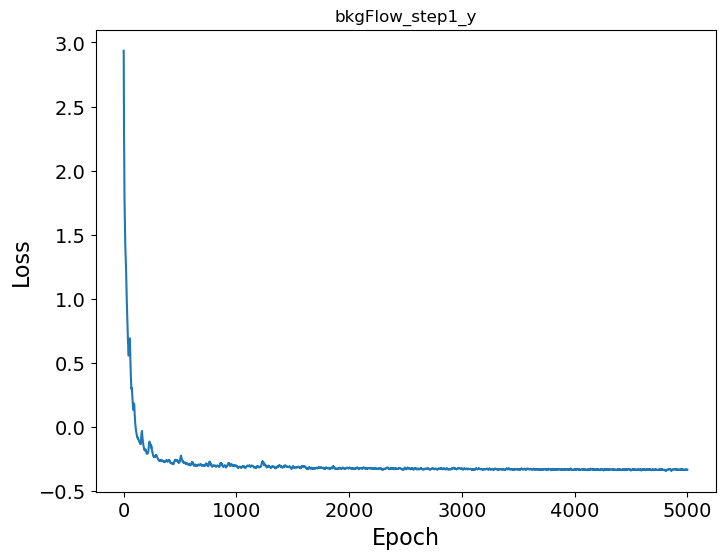

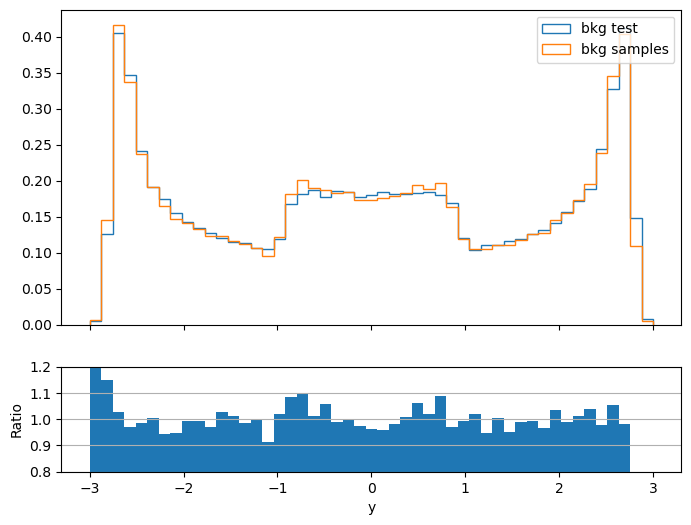

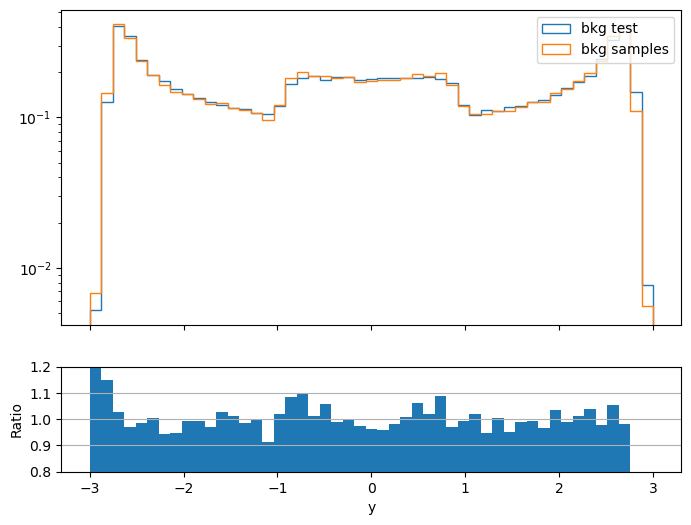

In [12]:
#NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":100,
#             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear"}
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":50,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 100
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_y


Loss: 1.1729184925556182, p = 48: 100%|██████████| 1000/1000 [03:59<00:00,  4.17it/s]


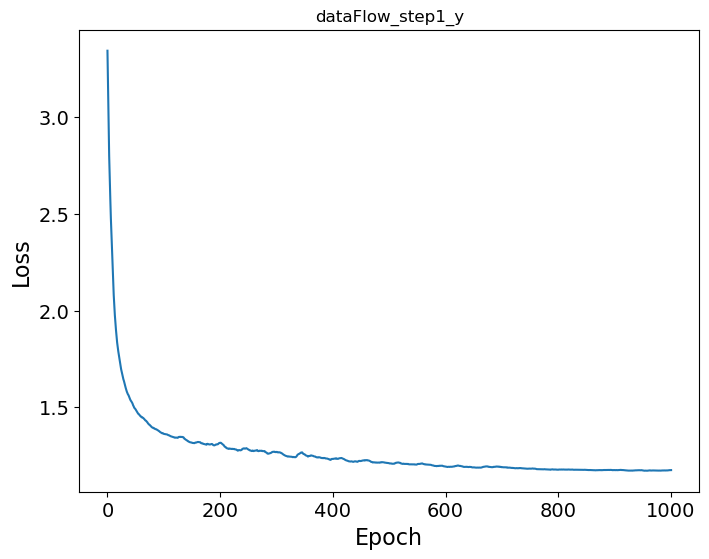

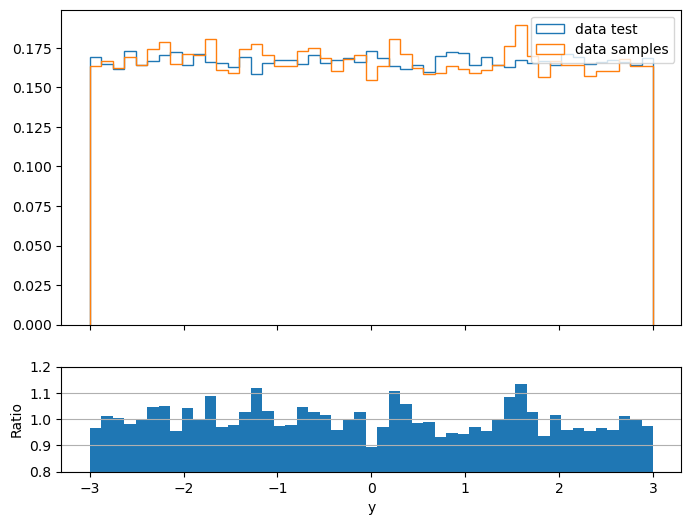

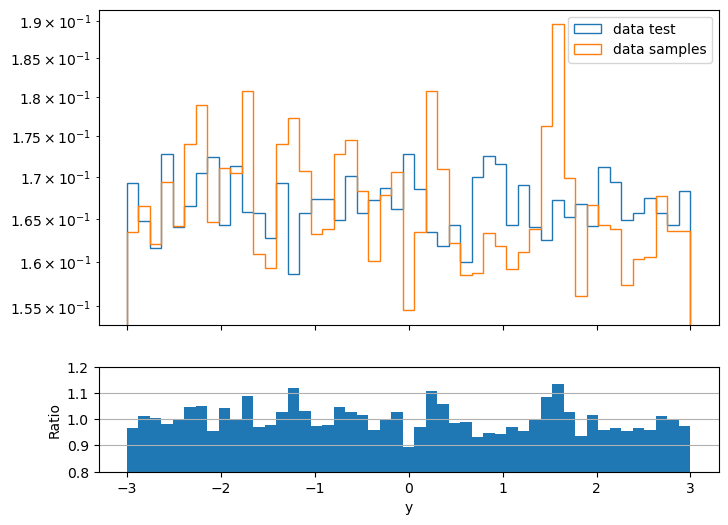

In [17]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":50,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear"}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*btrain.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs,anneal=True)
trainer.plotDensity(data=True)

[]


100%|██████████| 11/11 [00:00<00:00, 27.62it/s]


[0]


100%|██████████| 11/11 [00:00<00:00, 21.66it/s]


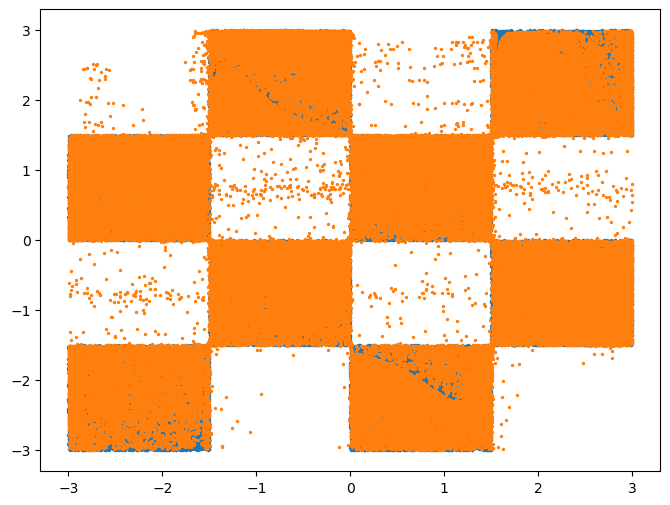

In [27]:
from datasets import CheckerboardDataset

corrector = qrnn.chainedNFCorrector("NF_models_QR_general/moons2check_v2/")

b,l1 = datasets.make_moons(100000,noise=0.02)
d = CheckerboardDataset(num_points=100000)[:].cpu().numpy()
b=minmax(b)
d=minmax(d)

bcorr = corrector.correctFull(b)
fitvars = ['x','y']
bcorr = np.concatenate([bcorr[v] for v in fitvars],axis=1)

plt.figure(figsize=(8,6))
plt.scatter(d[:,0],d[:,1],s=2)
plt.scatter(bcorr[:,0],bcorr[:,1],s=2)